In [1]:
# Import required libraries
# Set Python version requirements

import sys

assert sys.version_info[0] >= 3, "Python 3 is required."
assert sys.version_info[1] >= 6, "Python 3.6 or higher is required."

from platform import python_version

assert int(python_version().split(".")[1]) >= 5, (
    "Please upgrade your Python version following the instructions in \
	the README.md file found in the same directory as this notebook. Your Python version is "
    + python_version()
)

from gensim.models import KeyedVectors
from gensim.models import Word2Vec

import pprint
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [10, 5]

# Load the IMDB dataset from the huggingface datasets library
from datasets import load_dataset

imdb_dataset = load_dataset("stanfordnlp/imdb", name="plain_text")


import re
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

Using the latest cached version of the dataset since stanfordnlp/imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /home/zdy23/.cache/huggingface/datasets/stanfordnlp___imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Thu Aug 13 20:32:55 2026).


In [2]:
START_TOKEN = "<START>"
END_TOKEN = "<END>"
NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)


def read_corpus():
    """
    Read the IMDB dataset and return a list of sentences.
    Each sentence is a list of words.
    """
    files = imdb_dataset["train"]["text"][:NUM_SAMPLES]
    return [
        [START_TOKEN] + [re.sub(r"[^\w']", "", w.lower()) for w in f.split(" ")] + [END_TOKEN]
        for f in files
    ]


imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("corpus size: ", len(imdb_corpus[0]))

[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

In [3]:
def distinct_words(corpus):
    """
    Determine a list of distinct words for the corpus.
    Params:
        corpus (list of list of strings): corpus of documents
    Return:
        corpus_words (list of strings): sorted list of distinct words across the corpus
        n_corpus_words (integer): number of distinct words across the corpus
    """

    corpus_words = set()
    for sentence in corpus:
        corpus_words.update(sentence)
    corpus_words = sorted(list(corpus_words))
    n_corpus_words = len(corpus_words)

    return corpus_words, n_corpus_words

In [4]:
# -------------
# Sanity check
# -------------

# Define toy corpus
test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" "),
]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted(
    [START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN]
)
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert num_corpus_words == ans_num_corpus_words, (
    "Incorrect number of distinct words. Correct: {}. Yours: {}".format(
        ans_num_corpus_words, num_corpus_words
    )
)

# Test correct words
assert test_corpus_words == ans_test_corpus_words, (
    "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(
        str(ans_test_corpus_words), str(test_corpus_words)
    )
)

# Print Success
print("-" * 80)
print("Passed All Tests!")
print("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


In [5]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """Compute co-occurrence matrix for the given corpus and window_size (default of 4).

    Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
          number of co-occurring words.
          For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
          "All" will co-occur with "<START>", "that", "glitters", "is", and "not".

    Params:
        corpus (list of list of strings): corpus of documents
        window_size (int): size of context window

    Return:
        M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)):
            Co-occurence matrix of word counts.
            The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
        word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    words, n_words = distinct_words(corpus)
    word2ind = {word: idx for idx, word in enumerate(words)}
    M = np.zeros((n_words, n_words), dtype=np.int32)

    for doc in corpus:
        doc_len = len(doc)
        for t in range(doc_len):
            i = word2ind[doc[t]]
            left = max(0, t - window_size)
            right = min(doc_len, t + window_size + 1)
            for s in range(left, right):
                if t == s:
                    continue
                j = word2ind[doc[s]]
                M[i][j] += 1

    return M, word2ind

In [6]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

# Define toy corpus and get student's co-occurrence matrix
test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" "),
]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array(
    [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0],
        [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0],
        [1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0],
    ],
)
ans_test_corpus_words = sorted(
    [START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN]
)
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert word2ind_ans == word2ind_test, "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(
    word2ind_ans, word2ind_test
)

# Test correct M shape
assert M_test.shape == M_test_ans.shape, (
    "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)
)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError(
                "Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(
                    idx1, idx2, w1, w2, student, correct
                )
            )

# Print Success
print("-" * 80)
print("Passed All Tests!")
print("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### SVD - Reduce dimension

In [7]:
def reduce_to_k_dim(M, k=2):
	"""Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
	to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
		- http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html

	Params:
		M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
		k (int): embedding size of each word after dimension reduction
	Return:
		M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
				In terms of the SVD from math class, this actually returns U * S
	"""
	n_iters = 10
	print("Running Truncated SVD over %i words..." % (M.shape[0]))

	svd = TruncatedSVD(n_components=k, n_iter=n_iters)
	M_reduced = svd.fit_transform(M)

	print("Done.")
	return M_reduced

In [8]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness
# In fact we only check that your M_reduced has the right dimensions.
# ---------------------

# Define toy corpus and run student code
test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" "),
]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert M_test_reduced.shape[0] == 10, "M_reduced has {} rows; should have {}".format(
    M_test_reduced.shape[0], 10
)
assert M_test_reduced.shape[1] == 2, "M_reduced has {} columns; should have {}".format(
    M_test_reduced.shape[1], 2
)

# Print Success
print("-" * 80)
print("Passed All Tests!")
print("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


In [13]:
def plot_embeddings(M_reduced, word2ind, words):
	"""Plot in a scatterplot the embeddings of the words specified in the list "words".
	NOTE: do not plot all the words listed in M_reduced / word2ind.
	Include a label next to each point.

	Params:
		M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
		word2ind (dict): dictionary that maps word to indices for matrix M
		words (list of strings): words whose embeddings we want to visualize
	"""

	for word in words:
		idx = word2ind[word]
		x = M_reduced[idx, 0]
		y = M_reduced[idx, 1]
		plt.scatter(x, y, marker='x', color='red')
		plt.text(x, y, word, fontsize=9)
	plt.show()



--------------------------------------------------------------------------------
Outputted Plot:


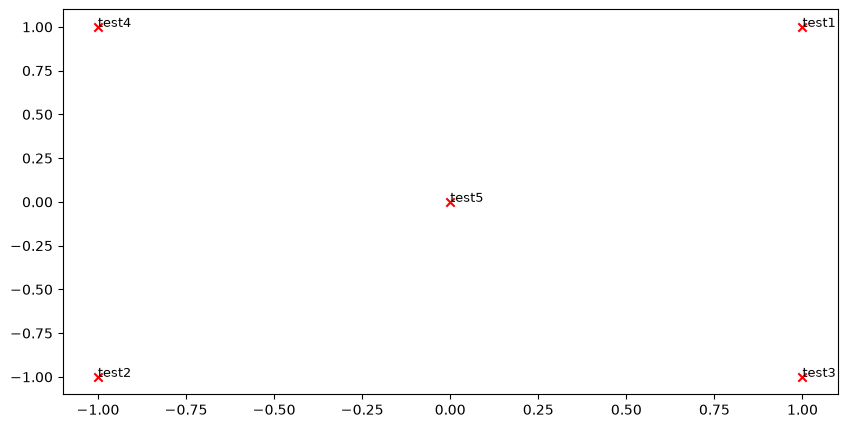

--------------------------------------------------------------------------------


In [14]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the included file question_1.4_test.png
# ---------------------

print("-" * 80)
print("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {"test1": 0, "test2": 1, "test3": 2, "test4": 3, "test5": 4}
words = ["test1", "test2", "test3", "test4", "test5"]
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print("-" * 80)


Running Truncated SVD over 5995 words...
Done.


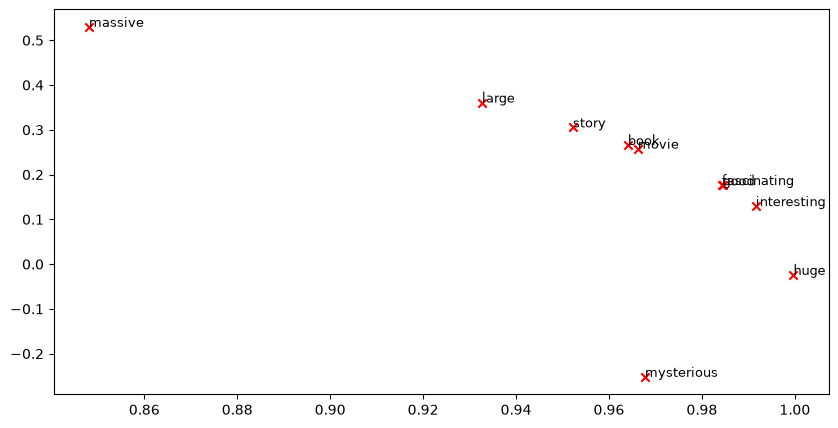

In [15]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis]  # broadcasting

words = [
    "movie",
    "book",
    "mysterious",
    "story",
    "fascinating",
    "good",
    "interesting",
    "large",
    "massive",
    "huge",
]

plot_embeddings(M_normalized, word2ind_co_occurrence, words)


**Verify that your figure matches "question_1.5.png" in the assignment zip. If not, use the figure in "question_1.5.png" to answer the next two questions.**

a. Find at least two groups of words that cluster together in 2-dimensional embedding space. Give an explanation for each cluster you observe.

- Cluster 1: story, book, movie

These three words cluster closely. They all refer to narrative creative works. In the training corpus, they share similar surrounding contexts and often appear in analogous sentence patterns, so their embeddings are close in the vector space.

- Cluster 2: fascinating, good, interesting

This group forms a tight cluster. All are positive descriptive adjectives used to evaluate content. They frequently modify similar nouns and have highly overlapping context distributions, resulting in nearby word embeddings.

b. What doesn't cluster together that you might think should have? Describe at least two examples.

- massive and huge  

They are near-synonyms meaning large in size, so we expect them to cluster. However, massive is far away from huge on the plot. This implies they co-occur with different sets of neighboring words in the training text.

- mysterious and interesting / fascinating

Intuitively, mysterious often describes stories and films and should lie close to other descriptive adjectives. But it appears isolated in the visualization. Its surrounding context words in the corpus differ significantly from those of interesting and fascinating.

## Part 2: Prediction-Based Word Vectors

As discussed in class, more recently prediction-based word vectors have demonstrated better performance, such as word2vec and GloVe (which also utilizes the benefit of counts). Here, we shall explore the embeddings produced by GloVe. Please revisit the class notes and lecture slides for more details on the word2vec and GloVe algorithms. If you're feeling adventurous, challenge yourself and try reading [GloVe's original paper](https://nlp.stanford.edu/pubs/glove.pdf).

Then run the following cells to load the GloVe vectors into memory. **Note**: If this is your first time to run these cells, i.e. download the embedding model, it will take a couple minutes to run. If you've run these cells before, rerunning them will load the model without redownloading it, which will take about 1 to 2 minutes.

In [16]:
def load_embedding_model():
    """Load GloVe Vectors
    Return:
        wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api

    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin


wv_from_bin = load_embedding_model()


[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000


In [17]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """Put the GloVe vectors into a matrix M.
    Param:
        wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
    Return:
        M: numpy matrix shape (num words, 200) containing the vectors
        word2ind: dictionary mapping each word to its row number in M
    """
    import random

    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind


In [18]:
# -----------------------------------------------------------------
# Run Cell to Reduce 200-Dimensional Word Embeddings to k Dimensions
# Note: This should be quick to run
# -----------------------------------------------------------------
M, word2ind = get_matrix_of_vectors(wv_from_bin, words)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]  # broadcasting


Shuffling words ...
Putting 400000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 400000 words...
Done.


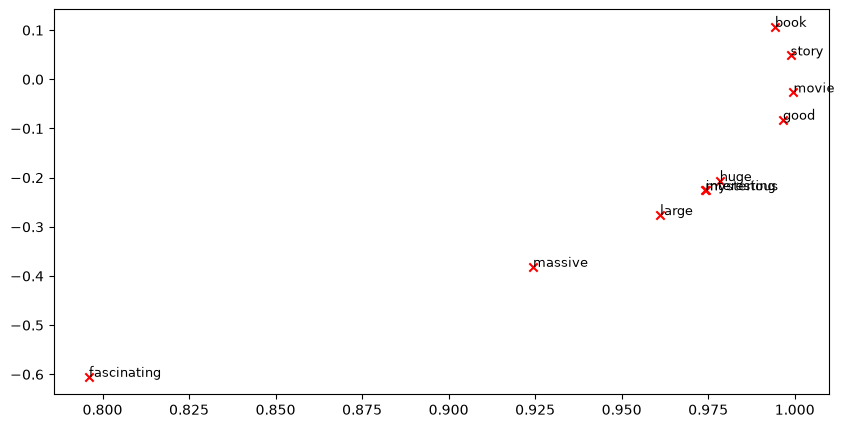

In [19]:
words = [
    "movie",
    "book",
    "mysterious",
    "story",
    "fascinating",
    "good",
    "interesting",
    "large",
    "massive",
    "huge",
]

plot_embeddings(M_reduced_normalized, word2ind, words)


**Verify that your figure matches "question_2.1.png" in the assignment zip. If not, use the figure in "question_2.1.png" (and the figure in "question_1.5.png", if applicable) to answer the next two questions.**

a. What is one way the plot is different from the one generated earlier from the co-occurrence matrix? What is one way it's similar?

- Difference

In the co-occurrence matrix plot (1.5), good and fascinating are located near each other in the same cluster. But in this GloVe plot, fascinating is isolated far away on the bottom-left, while good stays with book/story/movie.

- Similarity

In both plots, book, story, movie cluster closely together. These words all relate to narrative works, and their semantic relationship is captured in both embedding representations.


b. Why might the GloVe plot (question_2.1.png) differ from the plot generated earlier from the co-occurrence matrix (question_1.5.png)?

- Training objective difference:

The co-occurrence matrix only directly counts raw window co-occurrence frequency, with no optimization. GloVe is trained by minimizing a weighted least-squares loss on top of the co-occurrence statistics. It learns smoothed, low-dimensional embeddings that encode latent semantics rather than just raw counts.

- Scale of training data:

The co-occurrence matrix plot uses a tiny custom corpus, while these GloVe vectors are pre-trained on massive Wikipedia + Gigaword text. The contextual patterns and word relationships learned come from vastly more text.

- Dimensionality & compression:

Raw co-occurrence vectors are extremely high-dimensional and sparse. GloVe compresses information into dense low-dimensional vectors, which changes relative distances after projection into 2D space.


### Words with multiple meanings

In [ ]:
word = "bank"
top10 = wv_from_bin.most_similar(word, topn=10)
print(f"word: {word}")
for idx, (w, score) in enumerate(top10):
    print(f"{idx + 1}. {w}, similarity: {score:.4f}")


word: bank
1. banks, similarity: 0.7626
2. banking, similarity: 0.6819
3. central, similarity: 0.6284
4. financial, similarity: 0.6167
5. credit, similarity: 0.6050
6. lending, similarity: 0.5981
7. monetary, similarity: 0.5963
8. bankers, similarity: 0.5913
9. loans, similarity: 0.5803
10. investment, similarity: 0.5740


### Play CosineDistance

<img src="./imgs/inner_product.png" width=20% style="float: center;"></img>

In [21]:
w1 = "short"
w2 = "brief"
w3 = "long"

d12 = wv_from_bin.distance(w1, w2)
d13 = wv_from_bin.distance(w1, w3)

print(f"distance(w1,w2) = {d12:.4f}")
print(f"distance(w1,w3) = {d13:.4f}")
print(f"d(w1,w3) < d(w1,w2) ? {d13 < d12}")


distance(w1,w2) = 0.4749
distance(w1,w3) = 0.2302
d(w1,w3) < d(w1,w2) ? True


GloVe learns word embeddings from contextual distribution instead of abstract logical meaning.

Antonyms short and long frequently share similar contexts and modify the same kinds of nouns, which makes
their vectors close.

However, synonyms short and brief apply to different usage scenarios in the training data, with limited
overlapping contexts, resulting in greater vector distance.

In [23]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=["woman", "grandfather"], negative=["man"]))


[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623409390449524),
 ('grandson', 0.6618767976760864),
 ('grandparents', 0.644661009311676),
 ('wife', 0.6445354223251343)]


### Analogies with Word Vectors

In [24]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=["woman", "grandfather"], negative=["man"]))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623409390449524),
 ('grandson', 0.6618767976760864),
 ('grandparents', 0.644661009311676),
 ('wife', 0.6445354223251343)]


A working analogy is:

$$ \text{king} : \text{man} :: \text{queen} : \text{woman} $$

That is, the analogy "man : grandfather :: woman : x" corresponds to the vector relation

$$ \quad x \;\approx\; w + g - m.$$

Intuitively, $g - m$ captures the "one-generation-up" (grandparent) relationship, and adding that direction to $w$ ("woman") should land near "grandmother".

In [53]:
# another example

# x : a :: y : b
# [x, y] :: [b, a]

pprint.pprint(wv_from_bin.most_similar(positive=["king", "woman"], negative=["man"]))

[('queen', 0.6978678107261658),
 ('princess', 0.6081745028495789),
 ('monarch', 0.5889754891395569),
 ('throne', 0.5775108933448792),
 ('prince', 0.5750998258590698),
 ('elizabeth', 0.5463595986366272),
 ('daughter', 0.5399126410484314),
 ('kingdom', 0.5318052768707275),
 ('mother', 0.5168544054031372),
 ('crown', 0.5164473056793213)]


### Incorrect Analogy

In [27]:
pprint.pprint(wv_from_bin.most_similar(positive=["foot", "glove"], negative=["hand"]))

[('45,000-square', 0.4922032654285431),
 ('15,000-square', 0.4649604558944702),
 ('10,000-square', 0.4544755816459656),
 ('6,000-square', 0.44975775480270386),
 ('3,500-square', 0.444133460521698),
 ('700-square', 0.44257497787475586),
 ('50,000-square', 0.4356396794319153),
 ('3,000-square', 0.43486514687538147),
 ('30,000-square', 0.4330596923828125),
 ('footed', 0.43236875534057617)]


Word embeddings learn from contextual co-occurrence patterns rather than abstract semantic logic.

The linear analogy assumption only holds approximately.

The relationship between hand and glove cannot be perfectly represented by the same vector offset applicable to foot and sock. 

The contexts in which glove-hand appear are not symmetric with the contexts of sock-foot in the training corpus. 

Therefore, the vector arithmetic fails to retrieve the expected word sock.

In [44]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.

a, b, x, y = "night", "moon", "day", "sun"

# ------------------
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] != b


[('sky', 0.5423092842102051),
 ('bright', 0.4408645033836365),
 ('phoenix', 0.43481701612472534),
 ('mohegan', 0.42157432436943054),
 ('wukong', 0.4115796983242035),
 ('moon', 0.41032493114471436),
 ('blazing', 0.4090501070022583),
 ('jihai', 0.40874025225639343),
 ('lights', 0.4032285213470459),
 ('dappled', 0.4023444354534149)]


### Guided Analysis of Bias in Word Vectors

In [55]:
# Run this cell
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.

pprint.pprint(wv_from_bin.most_similar(positive=["man", "profession"], negative=["woman"]))
print()
pprint.pprint(wv_from_bin.most_similar(positive=["woman", "profession"], negative=["man"]))

[('reputation', 0.5250176787376404),
 ('professions', 0.5178037881851196),
 ('skill', 0.49046966433525085),
 ('skills', 0.49005505442619324),
 ('ethic', 0.4897659420967102),
 ('business', 0.487585186958313),
 ('respected', 0.485920250415802),
 ('practice', 0.482104629278183),
 ('regarded', 0.4778572916984558),
 ('life', 0.4760662019252777)]

[('professions', 0.5957457423210144),
 ('practitioner', 0.49884122610092163),
 ('teaching', 0.48292139172554016),
 ('nursing', 0.48211804032325745),
 ('vocation', 0.4788965880870819),
 ('teacher', 0.47160351276397705),
 ('practicing', 0.46937814354896545),
 ('educator', 0.46524327993392944),
 ('physicians', 0.4628995358943939),
 ('professionals', 0.4601394236087799)]
